# Citi Bike Daily Ridership Modeling (M1-M7)

This notebook completes the full modeling workflow requested in **Notebook 3 — model.ipynb**. It is organized by section **M1 through M7**, with explanations in both **English** and **French** so you can run it, study it, and reuse the wording in your assignment.

## M1: Split the Data

**English:** Load the clean dataset, define the target and features, and split the data into training and test sets using an 80/20 split. We keep `ride_date` out of the feature matrix because it identifies the row rather than acting as a usable feature; the trend feature from C4 carries the time information instead.

**Français :** Charger le jeu de données nettoyé, définir la variable cible et les variables explicatives, puis séparer les données en ensembles d'entraînement et de test avec une division 80/20. On garde `ride_date` hors de la matrice des variables, car cette colonne identifie la ligne mais n'est pas une vraie variable prédictive ; la variable de tendance de C4 transporte déjà l'information temporelle.

In [7]:
# ==================================================
# M1: Load Data and Split into Training/Test Sets
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# 1. Load the cleaned dataset
df = pd.read_csv('../data/citibike_weather_daily_clean.csv')


# 2. Make sure ride_date is stored as a datetime column
df['ride_date'] = pd.to_datetime(df['ride_date'])


# 3. Define the column we want the model to predict
target_col = 'num_rides'


# 4. Select the core model features
# ride_date is not included because it identifies the row.
# days_since_launch carries the usable time/trend information.
core_features = [
    'temp_f',
    'precip_in',
    'wind_speed_knots',
    'days_since_launch'
]


# 5. Add all one-hot-encoded day-of-week columns
day_dummy_cols = [
    col for col in df.columns
    if col.startswith('day_of_week_')
]

core_features += day_dummy_cols


# 6. Check that every feature exists before continuing
missing_features = [
    col for col in core_features
    if col not in df.columns
]

if missing_features:
    raise ValueError(
        f"These expected feature columns are missing: {missing_features}"
    )


# 7. Check whether the optional C5 feature exists
stretch_available = 'temp_f_squared' in df.columns


# 8. Create X (features) and y (target)
X = df[core_features].copy()
y = df[target_col].copy()


# 9. Split the data: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# 10. Confirm the results
print('Core features:')
print(core_features)

print('\nOptional temp_f_squared available:', stretch_available)

print('\nX_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

Core features:
['temp_f', 'precip_in', 'wind_speed_knots', 'days_since_launch', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday']

Optional temp_f_squared available: True

X_train shape: (1287, 10)
X_test shape: (322, 10)


## M2: Fit the Core Model

**English:** Fit a linear regression model on the training set using the core features: temperature, precipitation, wind, day-of-week indicators, and the trend feature. This is the baseline model that the later sections will evaluate and interpret.

**Français :** Entraîner un modèle de régression linéaire sur l'ensemble d'entraînement avec les variables principales : température, précipitations, vent, indicateurs du jour de la semaine et variable de tendance. Ce modèle sert de base pour les sections suivantes, qui vont l'évaluer et l'interpréter.

In [8]:
core_model = LinearRegression()
core_model.fit(X_train, y_train)

train_pred = core_model.predict(X_train)
test_pred = core_model.predict(X_test)

print('Model fitted successfully.')
print('Intercept:', core_model.intercept_)

Model fitted successfully.
Intercept: -8815.113890680666


## M3: Evaluate

**English:** Measure model performance with R² on both training and test sets, then compute MAE and RMSE on the test set in real units of rides. The test metrics matter more because they measure how well the model generalizes to unseen data rather than how well it memorizes the training set.

**Français :** Mesurer la performance du modèle avec le R² sur les ensembles d'entraînement et de test, puis calculer le MAE et le RMSE sur l'ensemble de test en unités réelles de trajets. Les métriques de test sont les plus importantes, car elles indiquent si le modèle généralise bien à de nouvelles données plutôt que de seulement bien s'ajuster aux données d'entraînement.

In [9]:
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f'Train R^2: {train_r2:.4f}')
print(f'Test R^2:  {test_r2:.4f}')
print(f'Test MAE:  {test_mae:,.2f} rides')
print(f'Test RMSE: {test_rmse:,.2f} rides')

Train R^2: 0.7294
Test R^2:  0.7505
Test MAE:  6,987.14 rides
Test RMSE: 8,875.80 rides


The core model achieved a training R² of 0.7294 and a test R² of 0.7505. This means that the model explains about 75% of the variation in daily Citi Bike ridership on unseen test data. The test score matters more than the training score because it measures how well the model generalizes to data that it did not use during training. The test MAE is 6,987 rides, meaning that the model is typically off by about 6,987 rides per day. The test RMSE is 8,876 rides, which is higher than the MAE and indicates that some days have especially large prediction errors.

**English interpretation template:**
- The test R² tells us what share of the variation in daily ridership the model explains on unseen data.
- We care more about the test R² than the training R² because the test score is a better measure of real predictive usefulness.
- The MAE means the model is typically off by about **___ rides** on a day.
- RMSE is at least as large as MAE; if RMSE is much larger, then a small number of badly missed days are contributing a lot of the total error.

**Modèle de phrase en français :**
- Le R² de test indique quelle part de la variation du nombre quotidien de trajets est expliquée par le modèle sur des données qu'il n'a jamais vues.
- On s'intéresse davantage au R² de test qu'au R² d'entraînement, car il mesure mieux l'utilité prédictive réelle du modèle.
- Le MAE signifie que le modèle se trompe en moyenne d'environ **___ trajets** par jour.
- Le RMSE est toujours au moins aussi grand que le MAE ; si l'écart est important, cela suggère que quelques journées sont très mal prédites et dominent l'erreur totale.

## M4: Interpret the Coefficients

**English:** Print each coefficient next to its feature name and interpret the most interesting ones in plain language. Coefficients are the model's claims about how one feature changes predicted ridership while holding the others constant.

**Français :** Afficher chaque coefficient à côté du nom de sa variable et interpréter les plus intéressants en langage simple. Les coefficients représentent ce que le modèle affirme sur l'effet d'une variable sur le nombre de trajets prévu, toutes les autres variables étant maintenues constantes.

In [10]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': core_model.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

coef_df

,feature,coefficient
6,day_of_week_Sunday,-7065.883098
5,day_of_week_Saturday,-5131.429499
1,precip_in,-3802.910097
7,day_of_week_Thursday,1941.072596
9,day_of_week_Wednesday,1601.813184
8,day_of_week_Tuesday,1083.430327
4,day_of_week_Monday,-929.472485
0,temp_f,562.110680
2,wind_speed_knots,-322.389242
3,days_since_launch,16.433640


**English interpretation template:**
- For a numeric variable like precipitation, a coefficient means: for each one-unit increase in that variable, the model changes the predicted number of rides by that many rides, holding the other variables fixed.
- For a dummy variable like `day_of_week_Monday`, the coefficient compares that day to the omitted reference day.
- Pick three interesting coefficients and translate them into plain English for the ops team. Also note whether the sign matches your EDA expectations.

**Modèle d'interprétation en français :**
- Pour une variable numérique comme les précipitations, le coefficient signifie : pour chaque augmentation d'une unité, le modèle modifie la prédiction d'autant de trajets, en gardant les autres variables constantes.
- Pour une variable indicatrice comme `day_of_week_Monday`, le coefficient compare ce jour au jour de référence omis.
- Choisissez trois coefficients intéressants et traduisez-les en langage simple pour l'équipe opérationnelle. Indiquez aussi si le signe correspond à ce que votre EDA laissait attendre.

In [6]:
df.columns.tolist()

['ride_date',
 'num_rides',
 'avg_duration_min',
 'temp_f',
 'max_temp_f',
 'min_temp_f',
 'wind_speed_knots',
 'precip_in',
 'month',
 'day_of_week_Monday',
 'day_of_week_Saturday',
 'day_of_week_Sunday',
 'day_of_week_Thursday',
 'day_of_week_Tuesday',
 'day_of_week_Wednesday',
 'days_since_launch',
 'temp_f_squared']

## M5: Diagnose With Residuals

**English:** Plot residuals in two ways: residuals versus predicted values and residuals versus ride date. If the plots show clumps, curves, or drift, that structure suggests the model is missing an important pattern.

**Français :** Tracer les résidus de deux façons : résidus en fonction des valeurs prédites et résidus en fonction de la date. Si les graphiques montrent des regroupements, des courbes ou une dérive, cela indique que le modèle rate probablement un motif important.

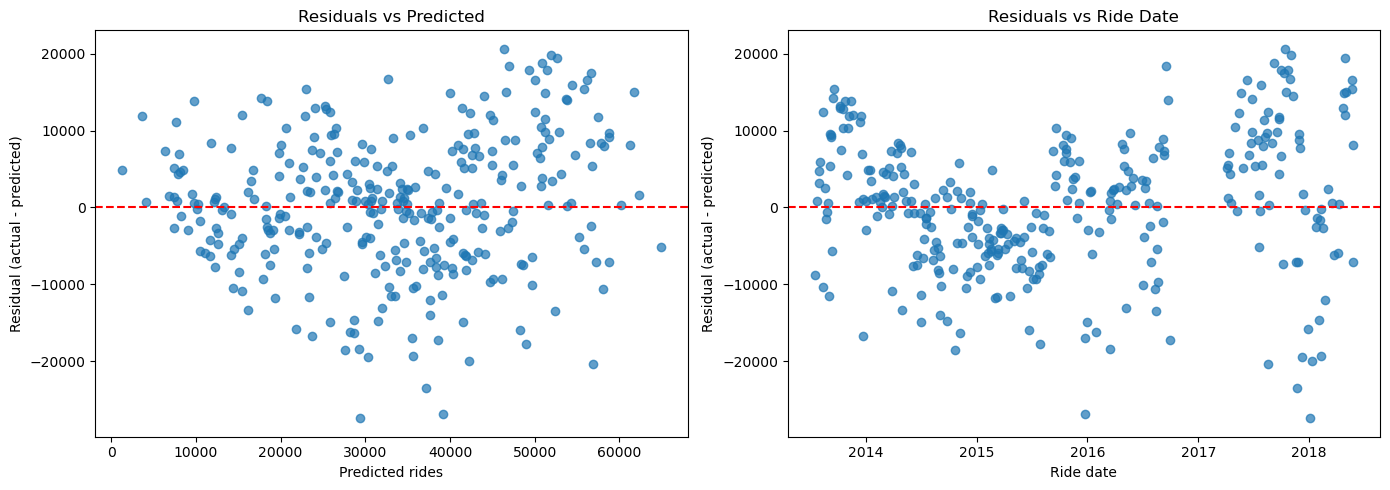

In [11]:
test_results = X_test.copy()
test_results['ride_date'] = df.loc[X_test.index, 'ride_date']
test_results['actual'] = y_test
test_results['predicted'] = test_pred
test_results['residual'] = test_results['actual'] - test_results['predicted']
test_results = test_results.sort_values('ride_date')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(test_results['predicted'], test_results['residual'], alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted rides')
axes[0].set_ylabel('Residual (actual - predicted)')

axes[1].scatter(test_results['ride_date'], test_results['residual'], alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Ride Date')
axes[1].set_xlabel('Ride date')
axes[1].set_ylabel('Residual (actual - predicted)')

plt.tight_layout()
plt.show()

**English interpretation template:**
- If the residuals are randomly scattered around zero, the model is doing a reasonable job.
- If there is a curve, the model may be missing a non-linear feature such as `temp_f_squared`.
- If there is upward or downward drift across dates, the model may still be missing a trend effect.

**Modèle d'interprétation en français :**
- Si les résidus sont dispersés aléatoirement autour de zéro, le modèle fait un travail raisonnable.
- S'il y a une courbe, le modèle manque peut-être une variable non linéaire comme `temp_f_squared`.
- S'il y a une dérive au fil du temps, le modèle manque peut-être encore un effet de tendance.

## M6: Improve One Thing

**English:** Based on the residual diagnosis, make one change, refit the model, and compare the new test R² with the original one. A good one-change improvement is to add `temp_f_squared` if you created it in C5. If the score gets worse, keep the result anyway because negative results are still informative.

**Français :** À partir du diagnostic des résidus, effectuer une seule modification, réentraîner le modèle, puis comparer le nouveau R² de test avec l'ancien. Une amélioration simple consiste à ajouter `temp_f_squared` si vous l'avez créé dans C5. Si le score devient moins bon, il faut quand même garder le résultat, car un résultat négatif reste informatif.

In [12]:
improved_features = core_features.copy()
change_description = 'No C5 stretch feature was available, so the comparison uses the same core feature set.'

if 'temp_f_squared' in df.columns and 'temp_f_squared' not in improved_features:
    improved_features.append('temp_f_squared')
    change_description = 'Added temp_f_squared to let the linear model capture a curved temperature relationship.'

X2 = df[improved_features].copy()
y2 = df[target_col].copy()

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

improved_model = LinearRegression()
improved_model.fit(X2_train, y2_train)

improved_test_pred = improved_model.predict(X2_test)
improved_test_r2 = r2_score(y2_test, improved_test_pred)
improved_test_mae = mean_absolute_error(y2_test, improved_test_pred)
improved_test_rmse = np.sqrt(mean_squared_error(y2_test, improved_test_pred))

comparison_df = pd.DataFrame({
    'model': ['Core model', 'Improved model'],
    'test_r2': [test_r2, improved_test_r2],
    'test_mae': [test_mae, improved_test_mae],
    'test_rmse': [test_rmse, improved_test_rmse]
})

print(change_description)
comparison_df

Added temp_f_squared to let the linear model capture a curved temperature relationship.


,model,test_r2,test_mae,test_rmse
0,Core model,0.750472,6987.141196,8875.799568
1,Improved model,0.761348,6748.938539,8680.222351


**English explanation template:**
I changed one thing in the model: **[describe the one change]**. The new test R² was **[new score]**, compared with **[old score]** before. This suggests that the change **[helped / did not help]** the model generalize to unseen data.

**Modèle d'explication en français :**
J'ai modifié un seul élément du modèle : **[décrire la modification]**. Le nouveau R² de test est **[nouveau score]**, contre **[ancien score]** auparavant. Cela suggère que cette modification **[a aidé / n'a pas aidé]** le modèle à mieux généraliser à de nouvelles données.

## M7: README Write-Up

Below is a draft summary you can adapt for your repository `README.md`. The lab asks for about 300–500 words for a semi-technical reader and especially wants the biggest weakness and the next data you would want.

### English Draft

In this project, I built a linear regression model to predict daily Citi Bike ridership using weather and calendar information. Before modeling, I cleaned the daily dataset by checking data types, handling missing values, encoding day of week as dummy variables, and creating a trend feature to reflect system growth over time. I used `days_since_launch` so the model could account for the fact that Citi Bike ridership increased over the years even when weather conditions were similar.

For the core model, I used temperature, precipitation, wind, day-of-week indicators, and the trend feature. I split the data into training and test sets so I could evaluate the model on unseen data instead of only measuring how well it fit the data it had already seen. I reported R² on both sets and also used MAE and RMSE on the test set to measure prediction error in rides, which is more interpretable for operations.

I also examined the fitted coefficients to understand how the model was relating weather and time to ridership. Then I plotted residuals against predicted values and against date to look for structure the model was missing. Residual patterns are important because they show whether the model is systematically wrong in certain situations rather than just making random errors.

The model's biggest weakness is that a simple linear regression cannot fully capture every factor that affects ridership. Weather helps explain some variation, but special events, station changes, holidays, transit disruptions, and other city-level factors are not included in this dataset. If I wanted to improve the model further, the next data I would want is holiday and event information, plus a better measure of network growth such as number of active stations or bikes available on each day.

### Brouillon en français

Dans ce projet, j'ai construit un modèle de régression linéaire pour prédire le nombre quotidien de trajets Citi Bike à partir d'informations météorologiques et calendaires. Avant la modélisation, j'ai nettoyé le jeu de données journalier en vérifiant les types de variables, en traitant les valeurs manquantes, en encodant le jour de la semaine avec des variables indicatrices, et en créant une variable de tendance pour représenter la croissance du système au fil du temps. J'ai utilisé `days_since_launch` afin que le modèle puisse tenir compte du fait que l'usage de Citi Bike a augmenté au fil des années même lorsque la météo était semblable.

Pour le modèle de base, j'ai utilisé la température, les précipitations, le vent, les indicateurs du jour de la semaine et la variable de tendance. J'ai séparé les données en ensembles d'entraînement et de test afin d'évaluer le modèle sur des données jamais vues, au lieu de mesurer seulement sa capacité à s'ajuster aux données d'entraînement. J'ai rapporté le R² sur les deux ensembles, ainsi que le MAE et le RMSE sur l'ensemble de test pour exprimer l'erreur directement en nombre de trajets, ce qui est plus facile à interpréter pour les opérations.

J'ai également examiné les coefficients estimés pour comprendre comment le modèle reliait la météo et le temps au nombre de trajets. Ensuite, j'ai tracé les résidus en fonction des prédictions et de la date afin de détecter une structure que le modèle ne capturait pas encore. Les résidus sont utiles parce qu'ils montrent si le modèle se trompe de façon systématique dans certaines situations plutôt que de faire seulement des erreurs aléatoires.

La plus grande faiblesse du modèle est qu'une régression linéaire simple ne peut pas capturer tous les facteurs qui influencent la fréquentation. La météo explique une partie de la variation, mais les événements spéciaux, les changements du réseau, les jours fériés, les perturbations du transport et d'autres facteurs urbains ne figurent pas dans ce jeu de données. Pour améliorer davantage le modèle, les prochaines données que je voudrais obtenir seraient des informations sur les jours fériés et les événements, ainsi qu'une meilleure mesure de la croissance du réseau, par exemple le nombre de stations actives ou le nombre de vélos disponibles chaque jour.

In [ ]:
# Optional helper cell: save coefficient table or metrics if you want
# coef_df.to_csv('model_coefficients.csv', index=False)
# comparison_df.to_csv('model_comparison.csv', index=False)